# 🚀 DDPG Agent for LunarLander-v3

**Deep Deterministic Policy Gradient (DDPG)** applied to the `LunarLanderContinuous-v3` environment from Gymnasium.

---
![lunar lander v3](https://gymnasium.farama.org/_images/lunar_lander.gif)
### Algorithm Overview
DDPG is an **actor-critic**, **model-free** algorithm designed for **continuous action spaces**. It combines:
- **Deterministic Policy Gradient** — actor outputs exact actions (not distributions)
- **Deep Q-Network ideas** — experience replay + target networks
- **Ornstein-Uhlenbeck noise** — temporally correlated exploration noise

| Component | Role |
|-----------|------|
| **Actor** | Maps state → action (policy) |
| **Critic** | Maps (state, action) → Q-value |
| **Target Networks** | Stabilize training via soft updates |
| **Replay Buffer** | Break temporal correlations |
| **OU Noise** | Encourage exploration |


## 📦 1. Installation & Imports

In [ ]:
# Install required packages
!pip install gymnasium[box2d] torch numpy matplotlib seaborn imageio pillow tqdm ipywidgets

In [19]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
from tqdm.auto import tqdm
import warnings
import imageio
import os
import copy
import time

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries loaded | Device: {DEVICE}')
print(f'   PyTorch {torch.__version__} | Gymnasium {gym.__version__}')

✅ Libraries loaded | Device: cuda
   PyTorch 2.11.0+cu130 | Gymnasium 1.2.3


## 🌍 2. Environment Exploration & Visualization

In [3]:
# ── Create environment ────────────────────────────────────────────────
env = gym.make('LunarLanderContinuous-v3')
env.reset(seed=SEED)

obs_dim  = env.observation_space.shape[0]
act_dim  = env.action_space.shape[0]
act_low  = env.action_space.low
act_high = env.action_space.high

STATE_LABELS = [
    'x position', 'y position',
    'x velocity', 'y velocity',
    'angle',      'angular velocity',
    'left leg contact', 'right leg contact'
]

print('══════════════════════════════════════════════════')
print('   LunarLanderContinuous-v3 — Environment Profile')
print('══════════════════════════════════════════════════')
print(f'  Observation space : {env.observation_space}')
print(f'  Action space      : {env.action_space}')
print(f'  Action low        : {act_low}')
print(f'  Action high       : {act_high}')
print()
print('  State variables:')
for i, label in enumerate(STATE_LABELS):
    print(f'    [{i}] {label}')
print()
print('  Action variables:')
print('    [0] Main engine thrust  (0 = off, 1 = full)')
print('    [1] Side engine thrust  (-1 = left, +1 = right)')
print('══════════════════════════════════════════════════')

══════════════════════════════════════════════════
   LunarLanderContinuous-v3 — Environment Profile
══════════════════════════════════════════════════
  Observation space : Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
  Action space      : Box(-1.0, 1.0, (2,), float32)
  Action low        : [-1. -1.]
  Action high       : [1. 1.]

  State variables:
    [0] x position
    [1] y position
    [2] x velocity
    [3] y velocity
    [4] angle
    [5] angular velocity
    [6] left leg contact
    [7] right leg contact

  Action variables:
    [0] Main engine thrust  (0 = off, 1 = full)
    [1] Side engine thrust  (-1 = left, +1 = right)
══════════════════════════════════════════════════


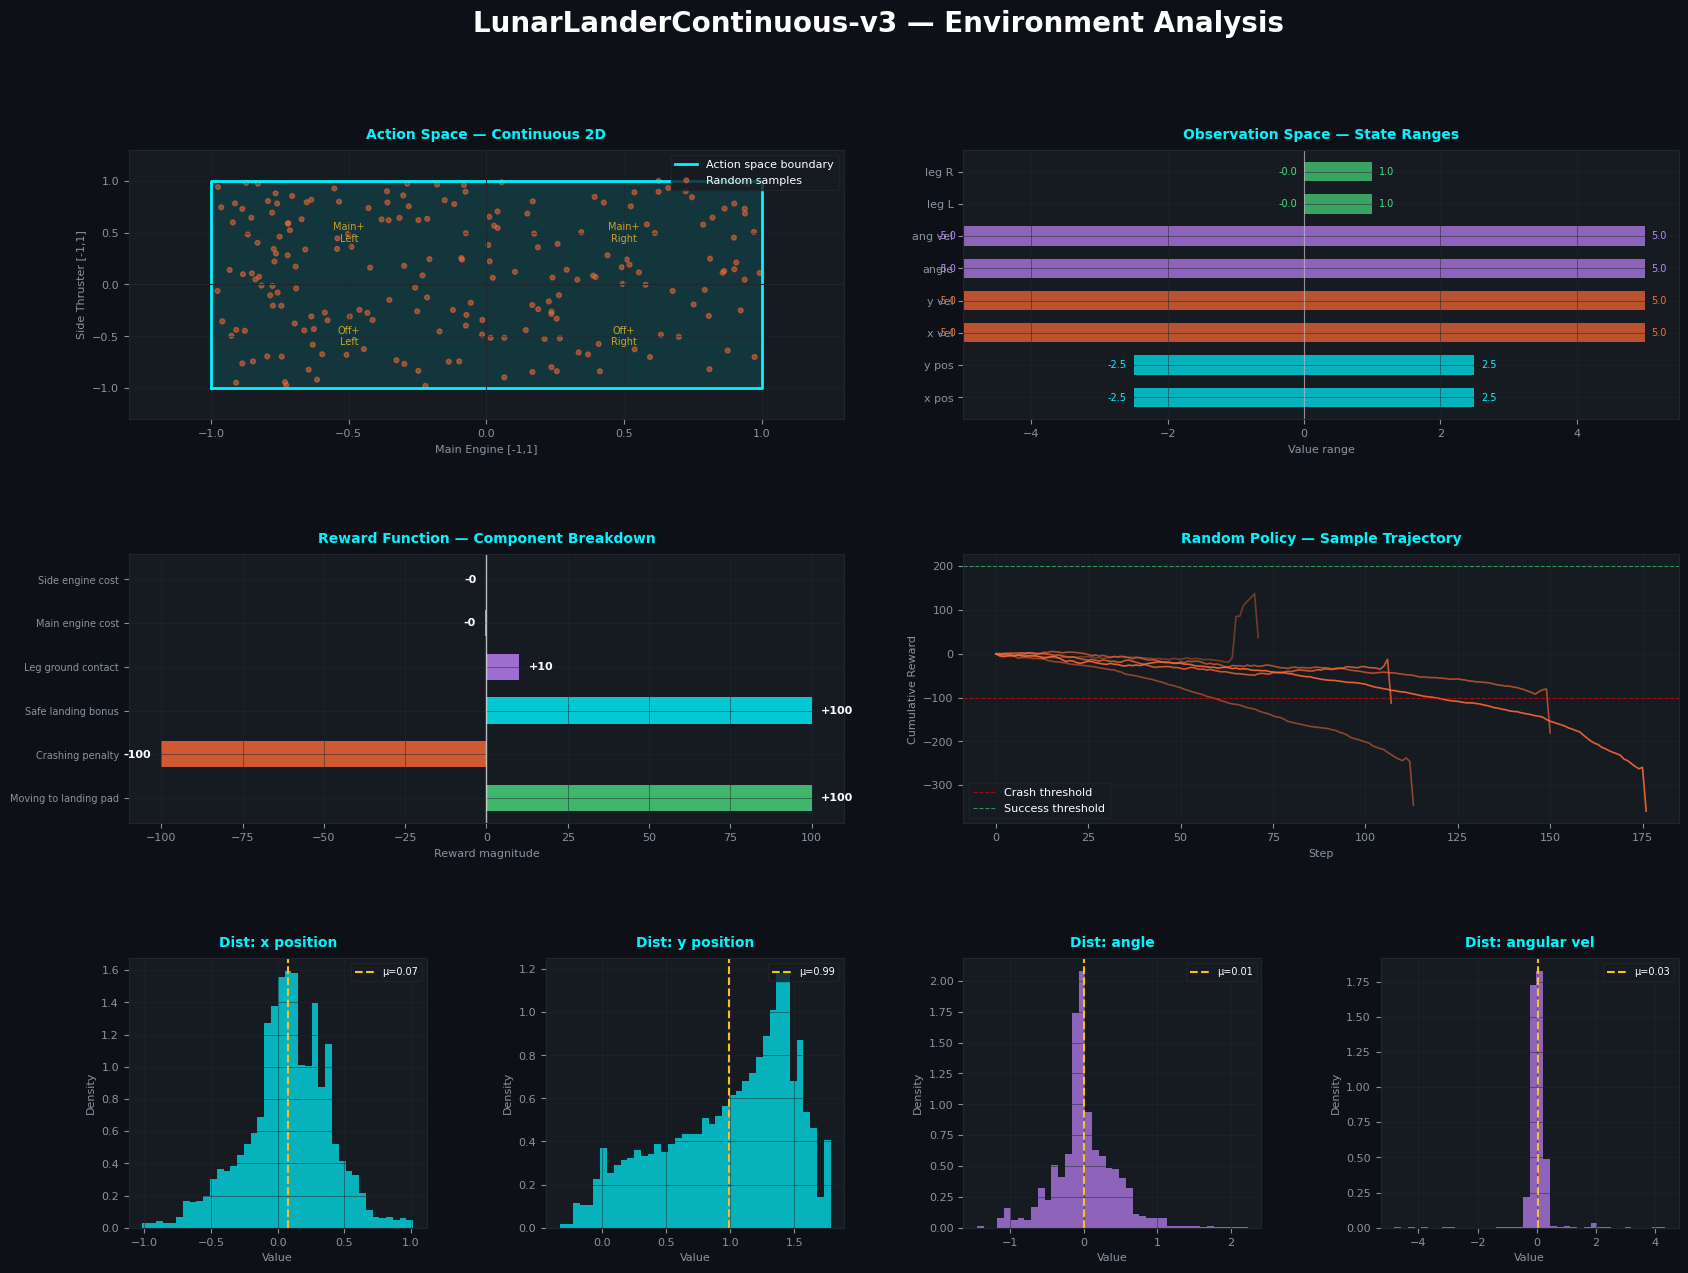

Environment analysis saved.


In [5]:
# ── Comprehensive Environment Visualization ───────────────────────────
fig = plt.figure(figsize=(20, 14), facecolor='#0d1117')
fig.suptitle('LunarLanderContinuous-v3 — Environment Analysis',
             fontsize=20, color='white', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

NEON   = '#00f5ff'
ORANGE = '#ff6b35'
PURPLE = '#c084fc'
GREEN  = '#4ade80'
YELLOW = '#fbbf24'
PANEL  = '#161b22'
GRID   = '#21262d'

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors='#8b949e', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.grid(True, color=GRID, linewidth=0.5, alpha=0.7)
    if title:  ax.set_title(title, color=NEON, fontsize=10, fontweight='bold', pad=8)
    if xlabel: ax.set_xlabel(xlabel, color='#8b949e', fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color='#8b949e', fontsize=8)

# ── Panel 1: Action Space ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1, 'Action Space — Continuous 2D', 'Main Engine [-1,1]', 'Side Thruster [-1,1]')

theta = np.linspace(0, 2*np.pi, 300)
# action space boundary
ax1.fill([-1,-1,1,1], [-1,1,1,-1], alpha=0.12, color=NEON)
ax1.plot([-1,-1,1,1,-1], [-1,1,1,-1,-1], color=NEON, linewidth=2, label='Action space boundary')

# sample random actions
rng_actions = np.random.uniform(-1, 1, (200, 2))
ax1.scatter(rng_actions[:,0], rng_actions[:,1],
            c=[ORANGE]*200, s=12, alpha=0.5, label='Random samples')

# annotate quadrants
annotations = [
    (0.5, 0.5, 'Main+\nRight'),
    (-0.5, 0.5, 'Main+\nLeft'),
    (0.5, -0.5, 'Off+\nRight'),
    (-0.5, -0.5, 'Off+\nLeft'),
]
for x, y, txt in annotations:
    ax1.text(x, y, txt, ha='center', va='center', color=YELLOW, fontsize=7, alpha=0.8)

ax1.axhline(0, color=GRID, linewidth=0.8)
ax1.axvline(0, color=GRID, linewidth=0.8)
ax1.legend(fontsize=8, labelcolor='white',
           facecolor=PANEL, edgecolor=GRID, loc='upper right')
ax1.set_xlim(-1.3, 1.3)
ax1.set_ylim(-1.3, 1.3)

# ── Panel 2: Observation Space ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2:])
style_ax(ax2, 'Observation Space — State Ranges')

obs_low  = env.observation_space.low
obs_high = env.observation_space.high
obs_low  = np.clip(obs_low,  -5, 5)
obs_high = np.clip(obs_high, -5, 5)

short_labels = ['x pos', 'y pos', 'x vel', 'y vel',
                'angle', 'ang vel', 'leg L', 'leg R']
colors_obs = [NEON, NEON, ORANGE, ORANGE, PURPLE, PURPLE, GREEN, GREEN]

y_pos = np.arange(len(short_labels))
for i, (lo, hi, col) in enumerate(zip(obs_low, obs_high, colors_obs)):
    ax2.barh(i, hi - lo, left=lo, height=0.6,
             color=col, alpha=0.7, edgecolor='none')
    ax2.text(hi + 0.1, i, f'{hi:.1f}', va='center', color=col, fontsize=7)
    ax2.text(lo - 0.1, i, f'{lo:.1f}', va='center', color=col, fontsize=7, ha='right')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(short_labels, color='#8b949e', fontsize=8)
ax2.axvline(0, color='white', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Value range', color='#8b949e', fontsize=8)

# ── Panel 3: Reward breakdown ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
style_ax(ax3, 'Reward Function — Component Breakdown')

reward_components = [
    ('Moving to landing pad', 100, GREEN),
    ('Crashing penalty', -100, ORANGE),
    ('Safe landing bonus', 100, NEON),
    ('Leg ground contact', 10, PURPLE),
    ('Main engine cost', -0.3, YELLOW),
    ('Side engine cost', -0.03, YELLOW),
]
labels_r = [r[0] for r in reward_components]
values_r = [r[1] for r in reward_components]
colors_r = [r[2] for r in reward_components]

bars = ax3.barh(labels_r, values_r, color=colors_r, alpha=0.8, height=0.6)
for bar, val in zip(bars, values_r):
    ax3.text(val + (3 if val >= 0 else -3), bar.get_y() + bar.get_height()/2,
             f'{val:+.0f}', va='center', ha='left' if val >= 0 else 'right',
             color='white', fontsize=8, fontweight='bold')
ax3.axvline(0, color='white', linewidth=1, alpha=0.7)
ax3.tick_params(axis='y', labelsize=7)
ax3.set_xlabel('Reward magnitude', color='#8b949e', fontsize=8)

# ── Panel 4: Sample trajectory with random policy ─────────────────────
ax4 = fig.add_subplot(gs[1, 2:])
style_ax(ax4, 'Random Policy — Sample Trajectory', 'Step', 'Cumulative Reward')

env_tmp = gym.make('LunarLanderContinuous-v3')
trajectories = []
for trial in range(5):
    obs, _ = env_tmp.reset(seed=trial)
    cum_rewards = [0]
    done = False
    while not done:
        action = env_tmp.action_space.sample()
        obs, reward, terminated, truncated, _ = env_tmp.step(action)
        cum_rewards.append(cum_rewards[-1] + reward)
        done = terminated or truncated
    trajectories.append(cum_rewards)
env_tmp.close()

for i, traj in enumerate(trajectories):
    alpha = 0.4 + 0.12 * i
    ax4.plot(traj, color=ORANGE, alpha=alpha, linewidth=1.2)

ax4.axhline(-100, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='Crash threshold')
ax4.axhline(200, color=GREEN, linestyle='--', linewidth=0.8, alpha=0.6, label='Success threshold')
ax4.legend(fontsize=8, labelcolor='white', facecolor=PANEL, edgecolor=GRID)

# ── Panel 5: State distribution from random rollout ───────────────────
ax_states = [fig.add_subplot(gs[2, i]) for i in range(4)]

env_tmp2 = gym.make('LunarLanderContinuous-v3')
all_obs = []
obs, _ = env_tmp2.reset(seed=0)
for _ in range(2000):
    action = env_tmp2.action_space.sample()
    obs, _, terminated, truncated, _ = env_tmp2.step(action)
    all_obs.append(obs)
    if terminated or truncated:
        obs, _ = env_tmp2.reset()
env_tmp2.close()

all_obs = np.array(all_obs)
plot_indices = [0, 1, 4, 5]  # x pos, y pos, angle, angular vel
plot_names   = ['x position', 'y position', 'angle', 'angular vel']
plot_colors  = [NEON, NEON, PURPLE, PURPLE]

for ax, idx, name, col in zip(ax_states, plot_indices, plot_names, plot_colors):
    style_ax(ax, f'Dist: {name}', 'Value', 'Density')
    ax.hist(all_obs[:, idx], bins=40, color=col, alpha=0.7,
            density=True, edgecolor='none')
    ax.axvline(all_obs[:, idx].mean(), color=YELLOW, linewidth=1.5,
               linestyle='--', label=f'μ={all_obs[:,idx].mean():.2f}')
    ax.legend(fontsize=7, labelcolor='white', facecolor=PANEL,
              edgecolor=GRID, loc='upper right')

plt.savefig('./env_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Environment analysis saved.')

## 🧠 3. DDPG Architecture

In [6]:
# ── Actor Network ─────────────────────────────────────────────────────
class Actor(nn.Module):
    """Deterministic policy: state → action."""

    def __init__(self, state_dim, action_dim, hidden=(400, 300)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden[0]), nn.LayerNorm(hidden[0]), nn.ReLU(),
            nn.Linear(hidden[0], hidden[1]), nn.LayerNorm(hidden[1]), nn.ReLU(),
            nn.Linear(hidden[1], action_dim), nn.Tanh()   # outputs ∈ [-1, 1]
        )
        self._init_weights()

    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
        # final layer small init for stability
        nn.init.uniform_(self.net[-2].weight, -3e-3, 3e-3)

    def forward(self, state):
        return self.net(state)


# ── Critic Network ────────────────────────────────────────────────────
class Critic(nn.Module):
    """Q-function: (state, action) → Q-value."""

    def __init__(self, state_dim, action_dim, hidden=(400, 300)):
        super().__init__()
        self.fc1  = nn.Linear(state_dim, hidden[0])
        self.ln1  = nn.LayerNorm(hidden[0])
        self.fc2  = nn.Linear(hidden[0] + action_dim, hidden[1])
        self.ln2  = nn.LayerNorm(hidden[1])
        self.fc3  = nn.Linear(hidden[1], 1)
        self._init_weights()

    def _init_weights(self):
        for layer in [self.fc1, self.fc2, self.fc3]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
        nn.init.uniform_(self.fc3.weight, -3e-3, 3e-3)

    def forward(self, state, action):
        x = F.relu(self.ln1(self.fc1(state)))
        x = torch.cat([x, action], dim=1)
        x = F.relu(self.ln2(self.fc2(x)))
        return self.fc3(x)


print('Actor  :', Actor(8, 2))
print('\nCritic :', Critic(8, 2))

Actor  : Actor(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=400, bias=True)
    (1): LayerNorm((400,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=400, out_features=300, bias=True)
    (4): LayerNorm((300,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=300, out_features=2, bias=True)
    (7): Tanh()
  )
)

Critic : Critic(
  (fc1): Linear(in_features=8, out_features=400, bias=True)
  (ln1): LayerNorm((400,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=402, out_features=300, bias=True)
  (ln2): LayerNorm((300,), eps=1e-05, elementwise_affine=True)
  (fc3): Linear(in_features=300, out_features=1, bias=True)
)


In [7]:
# ── Ornstein-Uhlenbeck Noise ──────────────────────────────────────────
class OUNoise:
    """Temporally correlated noise for exploration."""

    def __init__(self, size, mu=0.0, theta=0.15, sigma=0.2):
        self.size  = size
        self.mu    = mu * np.ones(size)
        self.theta = theta
        self.sigma = sigma
        self.reset()

    def reset(self):
        self.state = self.mu.copy()

    def sample(self):
        dx = self.theta * (self.mu - self.state) + \
             self.sigma * np.random.randn(self.size)
        self.state += dx
        return self.state.copy()


# ── Replay Buffer ─────────────────────────────────────────────────────
Transition = namedtuple('Transition',
                        ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    def __init__(self, capacity=int(1e6)):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)


print('✅ OUNoise & ReplayBuffer defined.')

✅ OUNoise & ReplayBuffer defined.


In [8]:
# ── DDPG Agent ────────────────────────────────────────────────────────
class DDPGAgent:
    def __init__(self,
                 state_dim, action_dim,
                 lr_actor=1e-4, lr_critic=1e-3,
                 gamma=0.99, tau=0.005,
                 buffer_size=int(1e6), batch_size=256):

        self.gamma      = gamma
        self.tau        = tau
        self.batch_size = batch_size

        # ── Networks ─────────────────────────────────────────────────
        self.actor        = Actor(state_dim, action_dim).to(DEVICE)
        self.actor_target = copy.deepcopy(self.actor)

        self.critic        = Critic(state_dim, action_dim).to(DEVICE)
        self.critic_target = copy.deepcopy(self.critic)

        self.actor_opt  = optim.Adam(self.actor.parameters(),  lr=lr_actor)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=lr_critic,
                                     weight_decay=1e-2)

        # ── Replay & Noise ────────────────────────────────────────────
        self.buffer = ReplayBuffer(buffer_size)
        self.noise  = OUNoise(action_dim)

        # ── Logging ───────────────────────────────────────────────────
        self.actor_losses  = []
        self.critic_losses = []

    # ──────────────────────────────────────────────────────────────────
    def select_action(self, state, add_noise=True, noise_scale=1.0):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        self.actor.eval()
        with torch.no_grad():
            action = self.actor(state_t).cpu().numpy()[0]
        self.actor.train()
        if add_noise:
            action += noise_scale * self.noise.sample()
        return np.clip(action, -1, 1)

    # ──────────────────────────────────────────────────────────────────
    def update(self):
        if len(self.buffer) < self.batch_size:
            return

        batch  = self.buffer.sample(self.batch_size)
        states = torch.FloatTensor(np.array(batch.state)).to(DEVICE)
        actions     = torch.FloatTensor(np.array(batch.action)).to(DEVICE)
        rewards     = torch.FloatTensor(np.array(batch.reward)).unsqueeze(1).to(DEVICE)
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(DEVICE)
        dones       = torch.FloatTensor(np.array(batch.done)).unsqueeze(1).to(DEVICE)

        # ── Critic update ─────────────────────────────────────────────
        with torch.no_grad():
            next_actions  = self.actor_target(next_states)
            target_q      = self.critic_target(next_states, next_actions)
            target_q      = rewards + self.gamma * (1 - dones) * target_q

        current_q    = self.critic(states, actions)
        critic_loss  = F.mse_loss(current_q, target_q)

        self.critic_opt.zero_grad()
        critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
        self.critic_opt.step()

        # ── Actor update ──────────────────────────────────────────────
        actor_loss = -self.critic(states, self.actor(states)).mean()

        self.actor_opt.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
        self.actor_opt.step()

        # ── Soft target update ────────────────────────────────────────
        for p, tp in zip(self.actor.parameters(), self.actor_target.parameters()):
            tp.data.copy_(self.tau * p.data + (1 - self.tau) * tp.data)
        for p, tp in zip(self.critic.parameters(), self.critic_target.parameters()):
            tp.data.copy_(self.tau * p.data + (1 - self.tau) * tp.data)

        self.actor_losses.append(actor_loss.item())
        self.critic_losses.append(critic_loss.item())

    # ──────────────────────────────────────────────────────────────────
    def save(self, path='ddpg_lunarlander.pt'):
        torch.save({
            'actor':  self.actor.state_dict(),
            'critic': self.critic.state_dict(),
        }, path)

    def load(self, path='ddpg_lunarlander.pt'):
        ckpt = torch.load(path, map_location=DEVICE)
        self.actor.load_state_dict(ckpt['actor'])
        self.critic.load_state_dict(ckpt['critic'])


print('✅ DDPGAgent defined.')

✅ DDPGAgent defined.


## 📊 4. Architecture Visualization

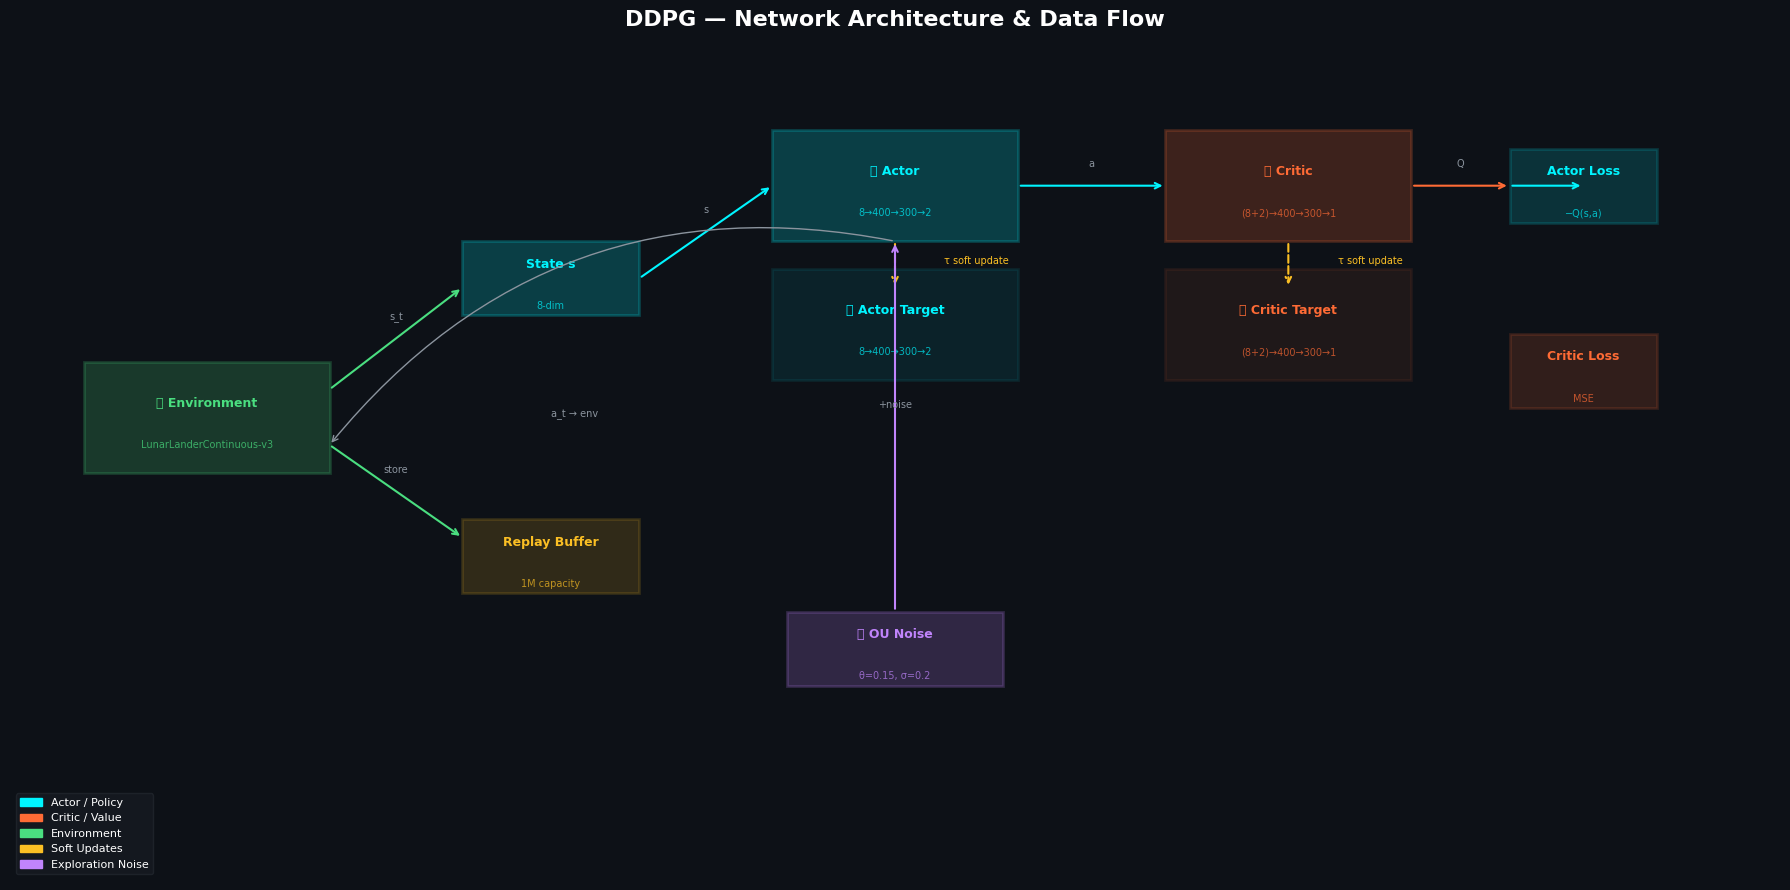

In [10]:
# ── DDPG Architecture Diagram ─────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(18, 9), facecolor='#0d1117')
ax.set_facecolor('#0d1117')
ax.set_xlim(0, 18)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_title('DDPG — Network Architecture & Data Flow',
             color='white', fontsize=16, fontweight='bold', pad=15)

def draw_box(ax, x, y, w, h, label, sublabel='', color=NEON, alpha=0.15):
    rect = plt.Rectangle((x - w/2, y - h/2), w, h,
                          facecolor=color, alpha=alpha,
                          edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y + (0.15 if sublabel else 0), label,
            ha='center', va='center', color=color,
            fontsize=9, fontweight='bold')
    if sublabel:
        ax.text(x, y - 0.3, sublabel, ha='center', va='center',
                color=color, fontsize=7, alpha=0.7)

def arrow(ax, x1, y1, x2, y2, label='', color='white'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=1.5, connectionstyle='arc3,rad=0'))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my + 0.2, label, ha='center', color='#8b949e', fontsize=7)

# Environment
draw_box(ax, 2, 5, 2.5, 1.2, '🌍 Environment', 'LunarLanderContinuous-v3', GREEN, 0.2)

# State
draw_box(ax, 5.5, 6.5, 1.8, 0.8, 'State s', '8-dim', NEON, 0.2)
draw_box(ax, 5.5, 3.5, 1.8, 0.8, 'Replay Buffer', '1M capacity', YELLOW, 0.15)

# Actor
draw_box(ax, 9, 7.5, 2.5, 1.2, '🎭 Actor', '8→400→300→2', NEON, 0.2)
draw_box(ax, 9, 6, 2.5, 1.2, '🎭 Actor Target', '8→400→300→2', NEON, 0.08)

# Critic
draw_box(ax, 13, 7.5, 2.5, 1.2, '🧮 Critic', '(8+2)→400→300→1', ORANGE, 0.2)
draw_box(ax, 13, 6, 2.5, 1.2, '🧮 Critic Target', '(8+2)→400→300→1', ORANGE, 0.08)

# OU Noise
draw_box(ax, 9, 2.5, 2.2, 0.8, '🔊 OU Noise', 'θ=0.15, σ=0.2', PURPLE, 0.2)

# Loss boxes
draw_box(ax, 16, 7.5, 1.5, 0.8, 'Actor Loss', '−Q(s,a)', NEON, 0.15)
draw_box(ax, 16, 5.5, 1.5, 0.8, 'Critic Loss', 'MSE', ORANGE, 0.15)

# Arrows
arrow(ax, 3.25, 5.3, 4.6, 6.4, 's_t', GREEN)
arrow(ax, 3.25, 4.7, 4.6, 3.7, 'store', GREEN)
arrow(ax, 6.4, 6.5, 7.75, 7.5, 's', NEON)
arrow(ax, 10.25, 7.5, 11.75, 7.5, 'a', NEON)
arrow(ax, 14.25, 7.5, 15.25, 7.5, 'Q', ORANGE)
arrow(ax, 15.25, 7.5, 16, 7.5, '', NEON)

# Soft update arrows
ax.annotate('', xy=(9, 6.4), xytext=(9, 6.9),
            arrowprops=dict(arrowstyle='->', color=YELLOW, lw=1.5,
                            linestyle='dashed'))
ax.text(9.5, 6.65, 'τ soft update', color=YELLOW, fontsize=7)
ax.annotate('', xy=(13, 6.4), xytext=(13, 6.9),
            arrowprops=dict(arrowstyle='->', color=YELLOW, lw=1.5,
                            linestyle='dashed'))
ax.text(13.5, 6.65, 'τ soft update', color=YELLOW, fontsize=7)

# Noise addition
arrow(ax, 9, 2.9, 9, 6.9, '+noise', PURPLE)

# Action to env
ax.annotate('', xy=(3.25, 4.7), xytext=(9, 6.9),
            arrowprops=dict(arrowstyle='->', color='#8b949e', lw=1,
                            connectionstyle='arc3,rad=0.3'))
ax.text(5.5, 5.0, 'a_t → env', color='#8b949e', fontsize=7)

# Legend
legend_items = [
    mpatches.Patch(color=NEON,   label='Actor / Policy'),
    mpatches.Patch(color=ORANGE, label='Critic / Value'),
    mpatches.Patch(color=GREEN,  label='Environment'),
    mpatches.Patch(color=YELLOW, label='Soft Updates'),
    mpatches.Patch(color=PURPLE, label='Exploration Noise'),
]
ax.legend(handles=legend_items, loc='lower left',
          facecolor=PANEL, edgecolor=GRID, labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('./architecture.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

## 🎬 5. Before Training — Random Policy Rendering

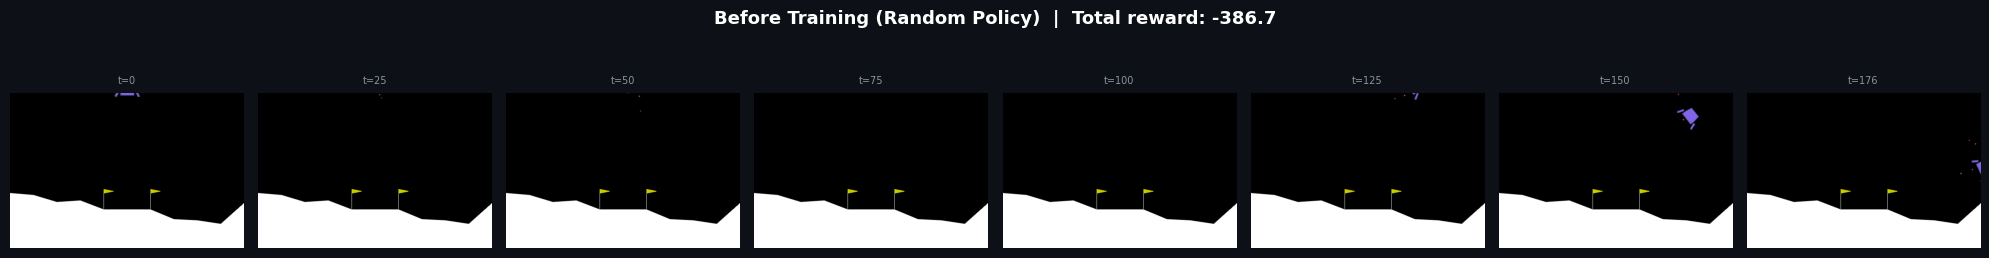

Random policy episode reward: -386.74


In [13]:
# ── Capture frames from random policy ────────────────────────────────
def capture_episode(policy_fn, env_name='LunarLanderContinuous-v3',
                    max_steps=400, seed=0):
    """Run one episode and return (frames, total_reward)."""
    env_r = gym.make(env_name, render_mode='rgb_array')
    obs, _ = env_r.reset(seed=seed)
    frames, total_reward = [], 0.0
    for _ in range(max_steps):
        frame = env_r.render()
        frames.append(frame)
        action = policy_fn(obs)
        obs, reward, terminated, truncated, _ = env_r.step(action)
        total_reward += reward
        if terminated or truncated:
            frames.append(env_r.render())
            break
    env_r.close()
    return frames, total_reward


def frames_to_gif(frames, path, fps=30):
    imageio.mimsave(path, frames, fps=fps)


def show_episode_strip(frames, title='', reward=0.0, n_frames=8):
    """Display a horizontal strip of evenly-spaced frames."""
    indices = np.linspace(0, len(frames)-1, n_frames, dtype=int)
    fig, axes = plt.subplots(1, n_frames, figsize=(20, 3), facecolor='#0d1117')
    fig.suptitle(f'{title}  |  Total reward: {reward:.1f}',
                 color='white', fontsize=13, fontweight='bold')
    for ax, idx in zip(axes, indices):
        ax.imshow(frames[idx])
        ax.set_title(f't={idx}', color='#8b949e', fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'./{title.replace(" ","_").lower()}_strip.png',
                dpi=120, bbox_inches='tight', facecolor='#0d1117')
    plt.show()


# Random policy
random_env = gym.make('LunarLanderContinuous-v3')
random_frames, random_reward = capture_episode(
    lambda obs: random_env.action_space.sample(), seed=42)
random_env.close()

frames_to_gif(random_frames, './before_training.gif', fps=25)
show_episode_strip(random_frames, 'Before Training (Random Policy)', random_reward)
print(f'Random policy episode reward: {random_reward:.2f}')

## 🏋️ 6. Training the DDPG Agent

In [14]:
# ── Hyperparameters ───────────────────────────────────────────────────
HP = dict(
    max_episodes  = 500,
    max_steps     = 1000,
    lr_actor      = 1e-4,
    lr_critic     = 1e-3,
    gamma         = 0.99,
    tau           = 0.005,
    batch_size    = 256,
    buffer_size   = int(1e6),
    warmup_steps  = 5000,   # pure random exploration before learning
    noise_decay   = 0.9995, # multiplicative noise scale decay
    noise_min     = 0.10,
    update_every  = 2,      # update networks every N steps
    save_every    = 100,    # save checkpoint every N episodes
    eval_every    = 25,     # evaluate (no noise) every N episodes
    eval_episodes = 3,
    solved_reward = 200,
)

print('Hyperparameters:')
for k, v in HP.items():
    print(f'  {k:20s}: {v}')

Hyperparameters:
  max_episodes        : 500
  max_steps           : 1000
  lr_actor            : 0.0001
  lr_critic           : 0.001
  gamma               : 0.99
  tau                 : 0.005
  batch_size          : 256
  buffer_size         : 1000000
  warmup_steps        : 5000
  noise_decay         : 0.9995
  noise_min           : 0.1
  update_every        : 2
  save_every          : 100
  eval_every          : 25
  eval_episodes       : 3
  solved_reward       : 200


In [18]:
# ── Training Loop ─────────────────────────────────────────────────────
train_env = gym.make('LunarLanderContinuous-v3')
agent = DDPGAgent(
    state_dim   = obs_dim,
    action_dim  = act_dim,
    lr_actor    = HP['lr_actor'],
    lr_critic   = HP['lr_critic'],
    gamma       = HP['gamma'],
    tau         = HP['tau'],
    buffer_size = HP['buffer_size'],
    batch_size  = HP['batch_size'],
)

# ── Logging ───────────────────────────────────────────────────────────
episode_rewards   = []
eval_rewards      = []
eval_episodes_log = []
steps_per_episode = []
noise_scales      = []

noise_scale  = 1.0
total_steps  = 0
best_eval    = -np.inf

print('Starting DDPG training...')
print('─' * 65)

pbar = tqdm(range(1, HP['max_episodes'] + 1), desc='Training')

for episode in pbar:
    state, _ = train_env.reset(seed=episode)
    agent.noise.reset()
    ep_reward = 0.0
    ep_steps  = 0

    for step in range(HP['max_steps']):
        total_steps += 1

        # Random warmup or policy action
        if total_steps < HP['warmup_steps']:
            action = train_env.action_space.sample()
        else:
            action = agent.select_action(state, add_noise=True,
                                         noise_scale=noise_scale)

        next_state, reward, terminated, truncated, _ = train_env.step(action)
        done = terminated or truncated

        agent.buffer.push(state, action, reward, next_state, float(done))

        # Update
        if total_steps >= HP['warmup_steps'] and \
           total_steps % HP['update_every'] == 0:
            agent.update()

        state       = next_state
        ep_reward  += reward
        ep_steps   += 1

        if done:
            break

    # Decay noise
    noise_scale = max(HP['noise_min'],
                      noise_scale * HP['noise_decay'])

    episode_rewards.append(ep_reward)
    steps_per_episode.append(ep_steps)
    noise_scales.append(noise_scale)

    # ── Periodic evaluation ───────────────────────────────────────────
    if episode % HP['eval_every'] == 0:
        eval_env = gym.make('LunarLanderContinuous-v3')
        er = []
        for e_ep in range(HP['eval_episodes']):
            s, _ = eval_env.reset(seed=1000 + e_ep)
            done = False
            r_sum = 0.0
            for _ in range(HP['max_steps']):
                a = agent.select_action(s, add_noise=False)
                s, r, term, trunc, _ = eval_env.step(a)
                r_sum += r
                if term or trunc:
                    break
            er.append(r_sum)
        eval_env.close()

        mean_eval = np.mean(er)
        eval_rewards.append(mean_eval)
        eval_episodes_log.append(episode)

        if mean_eval > best_eval:
            best_eval = mean_eval
            agent.save('./ddpg_best.pt')

    # ── Checkpoint ───────────────────────────────────────────────────
    if episode % HP['save_every'] == 0:
        agent.save(f'./ddpg_ep{episode}.pt')

    # ── Progress bar update ───────────────────────────────────────────
    avg100 = np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100 \
             else np.mean(episode_rewards)
    pbar.set_postfix({
        'ep_reward': f'{ep_reward:.1f}',
        'avg100':    f'{avg100:.1f}',
        'best_eval': f'{best_eval:.1f}',
        'noise':     f'{noise_scale:.3f}',
        'buffer':    len(agent.buffer),
    })

    # Early stop if solved
    if avg100 >= HP['solved_reward'] and episode >= 100:
        print(f'\n🎉 Solved at episode {episode}! Avg100 = {avg100:.2f}')
        agent.save('./ddpg_solved.pt')
        break

train_env.close()
print('\n✅ Training complete.')
print(f'   Best eval reward : {best_eval:.2f}')
print(f'   Total steps      : {total_steps:,}')

Starting DDPG training...
─────────────────────────────────────────────────────────────────



Exception ignored in: <function tqdm.__del__ at 0x7ac97d9ab420>
Traceback (most recent call last):
  File "/home/hem436/miniconda3/envs/harvim/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/hem436/miniconda3/envs/harvim/lib/python3.13/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
Training: 100%|██████████| 500/500 [10:21<00:00,  1.24s/it, ep_reward=-18.5, avg100=-35.4, best_eval=13.8, noise=0.779, buffer=241982]


✅ Training complete.
   Best eval reward : 13.78
   Total steps      : 241,982


## 📈 7. Training Visualizations

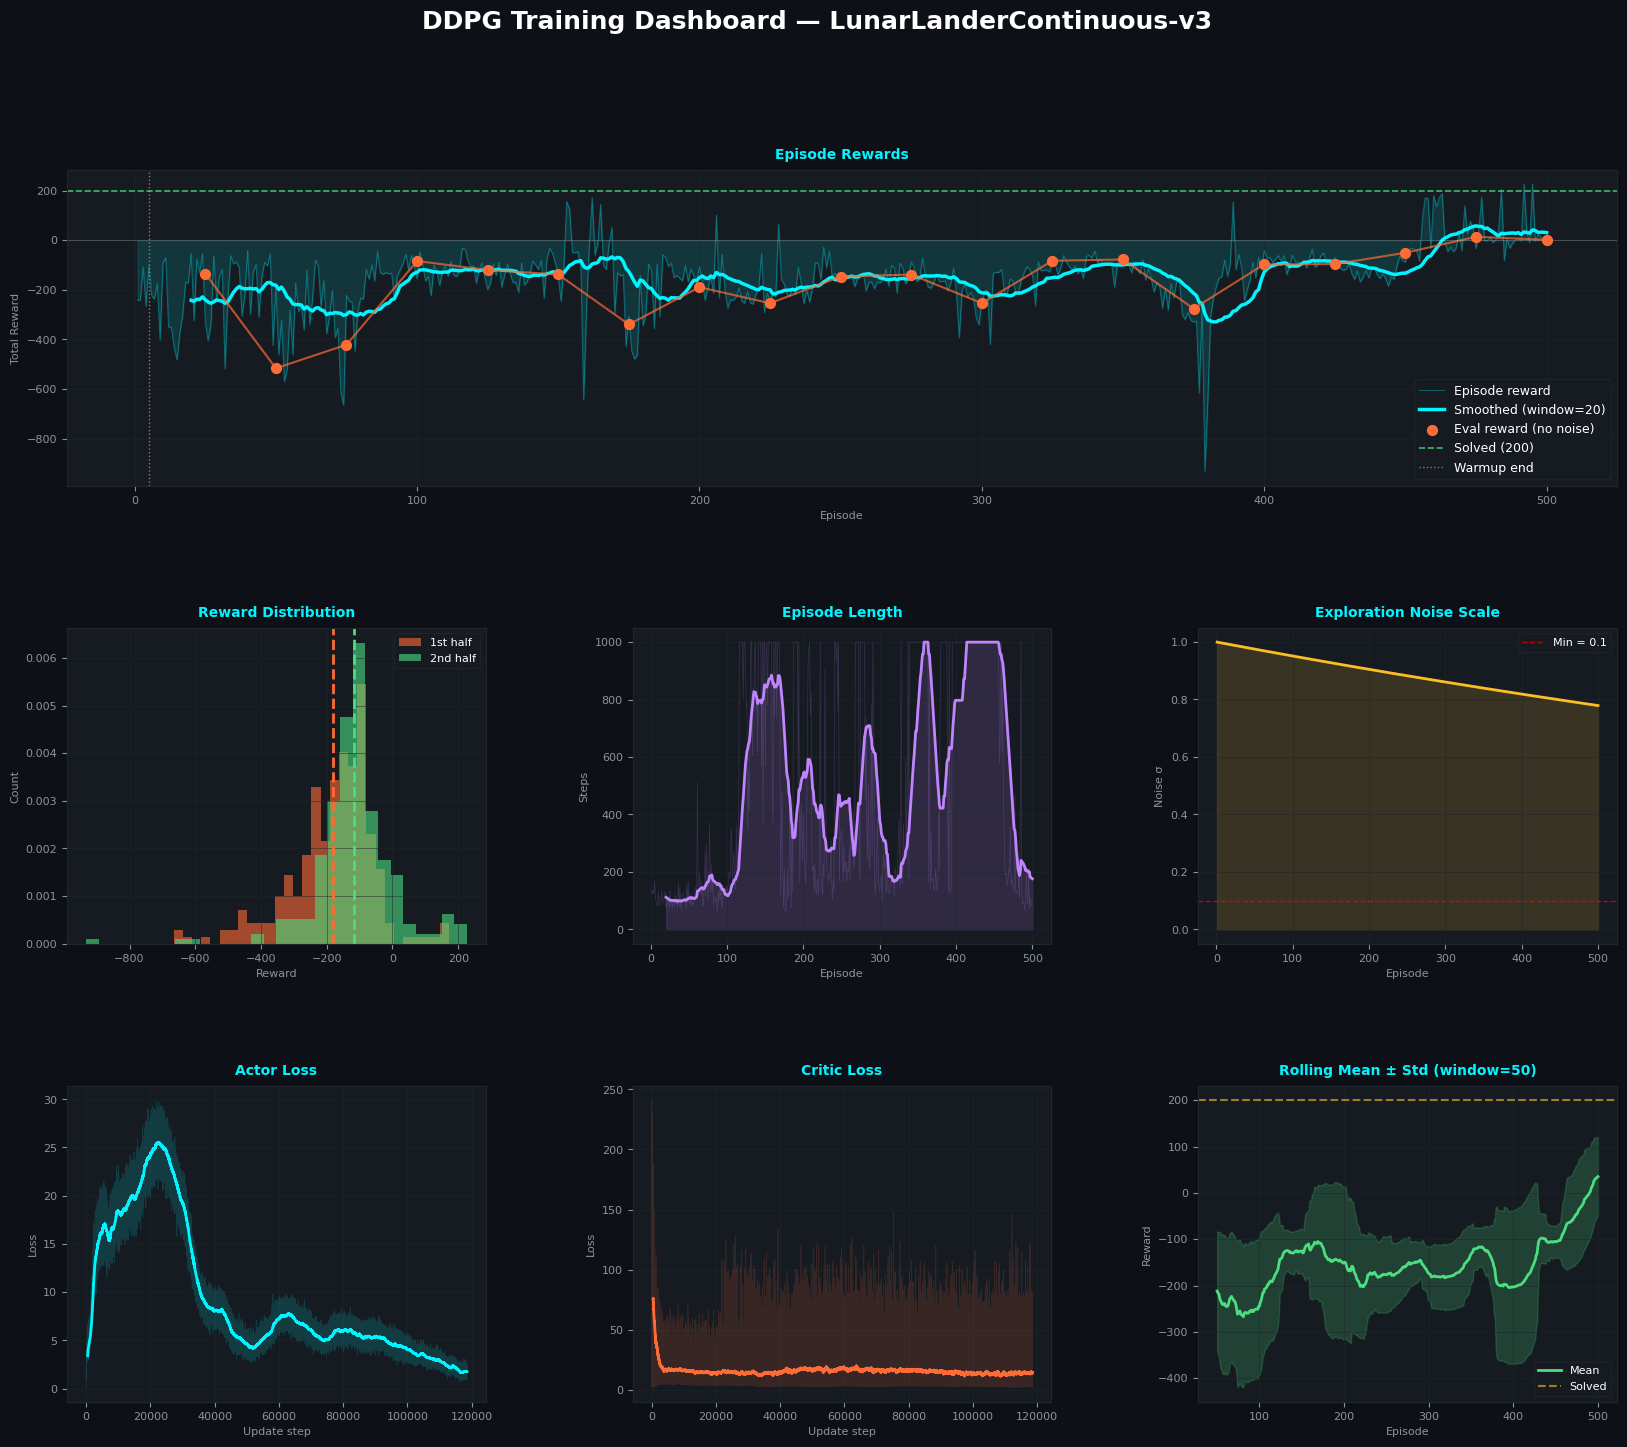

Training dashboard saved.


In [20]:
# ── Comprehensive Training Dashboard ─────────────────────────────────
fig = plt.figure(figsize=(20, 16), facecolor='#0d1117')
fig.suptitle('DDPG Training Dashboard — LunarLanderContinuous-v3',
             fontsize=18, color='white', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ep_arr    = np.arange(1, len(episode_rewards) + 1)
window    = 20
smoothed  = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
smooth_ep = ep_arr[window-1:]

# ── 1. Episode Reward ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1, 'Episode Rewards', 'Episode', 'Total Reward')

ax1.fill_between(ep_arr, episode_rewards, alpha=0.12, color=NEON)
ax1.plot(ep_arr, episode_rewards, color=NEON, alpha=0.3, linewidth=0.7, label='Episode reward')
ax1.plot(smooth_ep, smoothed, color=NEON, linewidth=2.5, label=f'Smoothed (window={window})')

if eval_rewards:
    ax1.scatter(eval_episodes_log, eval_rewards,
                color=ORANGE, s=50, zorder=5, label='Eval reward (no noise)')
    ax1.plot(eval_episodes_log, eval_rewards,
             color=ORANGE, linewidth=1.5, alpha=0.7)

ax1.axhline(200, color=GREEN, linestyle='--', linewidth=1.2, alpha=0.8, label='Solved (200)')
ax1.axhline(0,   color='white', linewidth=0.5, alpha=0.3)
ax1.axvline(HP['warmup_steps'] / max(steps_per_episode + [1]),
            color=YELLOW, linewidth=1, linestyle=':', alpha=0.6, label='Warmup end')
ax1.legend(facecolor=PANEL, edgecolor=GRID, labelcolor='white', fontsize=9)

# ── 2. Reward Distribution ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
style_ax(ax2, 'Reward Distribution', 'Reward', 'Count')

n_ep = len(episode_rewards)
first_half  = episode_rewards[:n_ep//2]
second_half = episode_rewards[n_ep//2:]
ax2.hist(first_half,  bins=30, color=ORANGE, alpha=0.6, label='1st half', density=True)
ax2.hist(second_half, bins=30, color=GREEN,  alpha=0.6, label='2nd half', density=True)
ax2.axvline(np.mean(first_half),  color=ORANGE, linewidth=2, linestyle='--')
ax2.axvline(np.mean(second_half), color=GREEN,  linewidth=2, linestyle='--')
ax2.legend(facecolor=PANEL, edgecolor=GRID, labelcolor='white', fontsize=8)

# ── 3. Steps per Episode ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
style_ax(ax3, 'Episode Length', 'Episode', 'Steps')
smoothed_steps = np.convolve(steps_per_episode, np.ones(window)/window, mode='valid')
ax3.fill_between(smooth_ep, smoothed_steps, alpha=0.15, color=PURPLE)
ax3.plot(smooth_ep, smoothed_steps, color=PURPLE, linewidth=2)
ax3.plot(ep_arr, steps_per_episode, color=PURPLE, alpha=0.2, linewidth=0.5)

# ── 4. Noise Scale ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
style_ax(ax4, 'Exploration Noise Scale', 'Episode', 'Noise σ')
ax4.plot(ep_arr, noise_scales, color=YELLOW, linewidth=2)
ax4.fill_between(ep_arr, noise_scales, alpha=0.15, color=YELLOW)
ax4.axhline(HP['noise_min'], color='red', linestyle='--',
            linewidth=1, alpha=0.7, label=f'Min = {HP["noise_min"]}')
ax4.legend(facecolor=PANEL, edgecolor=GRID, labelcolor='white', fontsize=8)

# ── 5. Actor Loss ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
style_ax(ax5, 'Actor Loss', 'Update step', 'Loss')
if agent.actor_losses:
    al = np.array(agent.actor_losses)
    sw = min(500, len(al)//4 or 1)
    smoothed_al = np.convolve(al, np.ones(sw)/sw, mode='valid')
    ax5.plot(al, color=NEON, alpha=0.15, linewidth=0.5)
    ax5.plot(range(sw-1, len(al)), smoothed_al, color=NEON, linewidth=2)

# ── 6. Critic Loss ───────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
style_ax(ax6, 'Critic Loss', 'Update step', 'Loss')
if agent.critic_losses:
    cl = np.array(agent.critic_losses)
    sw = min(500, len(cl)//4 or 1)
    smoothed_cl = np.convolve(cl, np.ones(sw)/sw, mode='valid')
    ax6.plot(cl, color=ORANGE, alpha=0.15, linewidth=0.5)
    ax6.plot(range(sw-1, len(cl)), smoothed_cl, color=ORANGE, linewidth=2)

# ── 7. Rolling Stats ─────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
style_ax(ax7, 'Rolling Mean ± Std (window=50)', 'Episode', 'Reward')
W = 50
if len(episode_rewards) >= W:
    roll_mean = [np.mean(episode_rewards[max(0,i-W):i]) for i in range(W, len(episode_rewards)+1)]
    roll_std  = [np.std( episode_rewards[max(0,i-W):i]) for i in range(W, len(episode_rewards)+1)]
    x_roll    = ep_arr[W-1:]
    roll_mean = np.array(roll_mean)
    roll_std  = np.array(roll_std)
    ax7.plot(x_roll, roll_mean, color=GREEN, linewidth=2, label='Mean')
    ax7.fill_between(x_roll, roll_mean - roll_std, roll_mean + roll_std,
                     alpha=0.2, color=GREEN)
    ax7.axhline(200, color=YELLOW, linestyle='--', alpha=0.6, label='Solved')
    ax7.legend(facecolor=PANEL, edgecolor=GRID, labelcolor='white', fontsize=8)

plt.savefig('./training_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Training dashboard saved.')

## 🎬 8. After Training — Trained Agent Rendering

Loaded best checkpoint: ./ddpg_best.pt


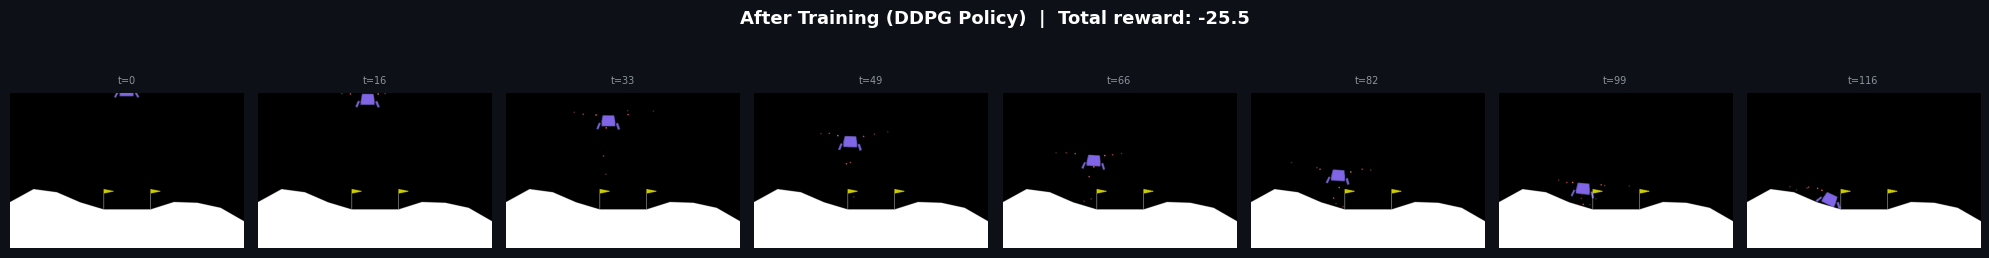

Trained policy episode reward: -25.54


In [21]:
# ── Load best checkpoint & evaluate ──────────────────────────────────
best_ckpt = './ddpg_best.pt'
if os.path.exists(best_ckpt):
    agent.load(best_ckpt)
    print(f'Loaded best checkpoint: {best_ckpt}')

# Capture trained episode
trained_frames, trained_reward = capture_episode(
    lambda obs: agent.select_action(obs, add_noise=False),
    seed=7)

frames_to_gif(trained_frames, './after_training.gif', fps=30)
show_episode_strip(trained_frames, 'After Training (DDPG Policy)', trained_reward)
print(f'Trained policy episode reward: {trained_reward:.2f}')

## 🆚 9. Before vs After Comparison

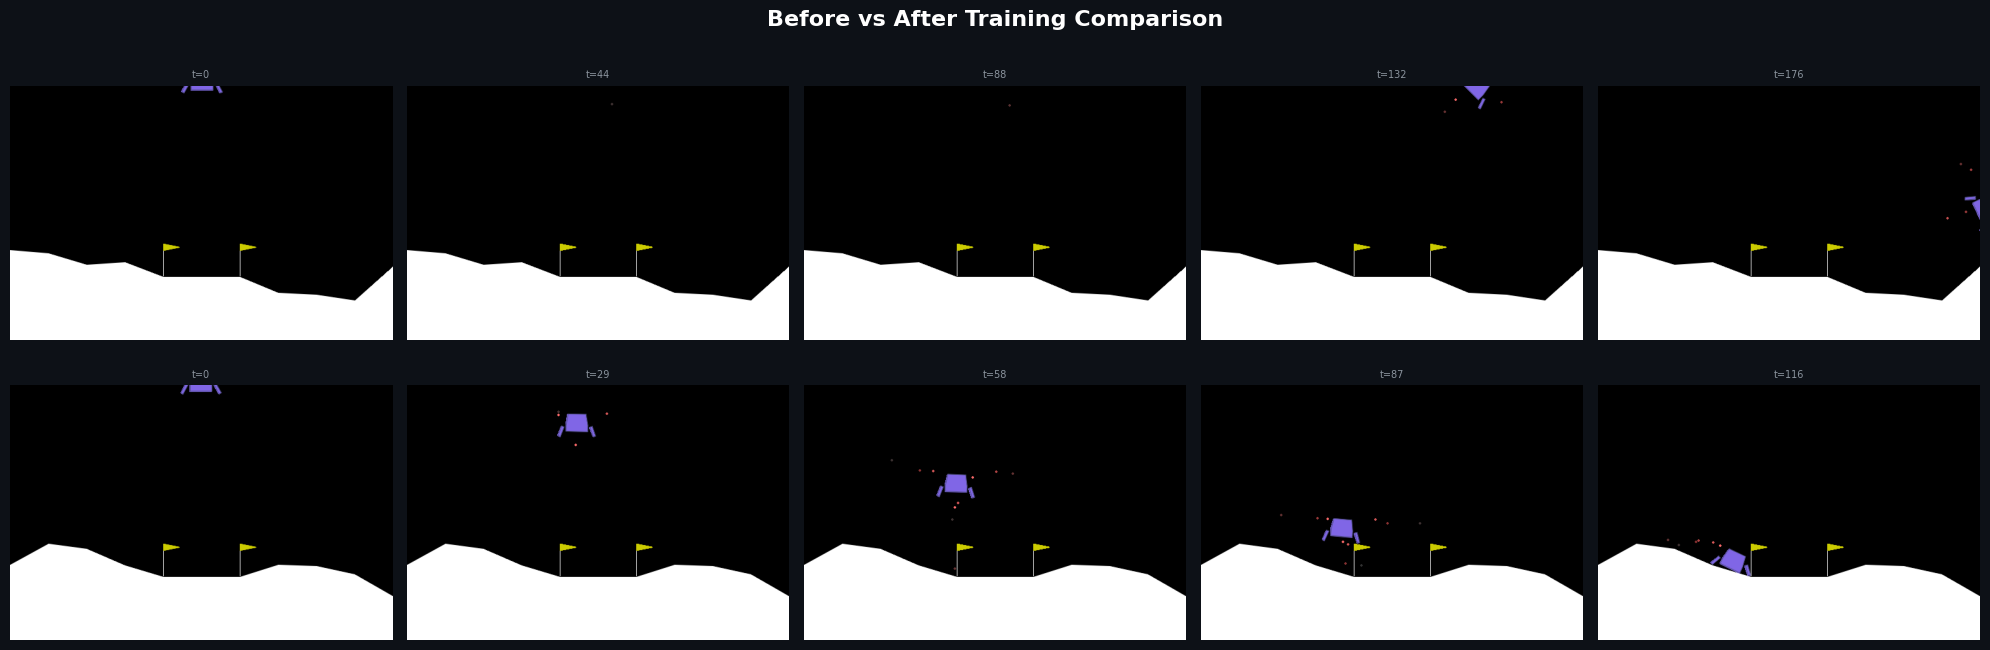

In [22]:
# ── Side-by-side comparison strip ────────────────────────────────────
n_show = 5
rand_idx    = np.linspace(0, len(random_frames)-1,  n_show, dtype=int)
trained_idx = np.linspace(0, len(trained_frames)-1, n_show, dtype=int)

fig, axes = plt.subplots(2, n_show, figsize=(20, 7), facecolor='#0d1117')
fig.suptitle('Before vs After Training Comparison',
             fontsize=16, color='white', fontweight='bold')

titles_row = [
    f'Random Policy  (reward: {random_reward:.0f})',
    f'DDPG Policy    (reward: {trained_reward:.0f})'
]
colors_row = [ORANGE, GREEN]

for row, (frames, indices, title, col) in enumerate(zip(
        [random_frames, trained_frames],
        [rand_idx, trained_idx],
        titles_row, colors_row)):
    for col_i, idx in enumerate(indices):
        ax = axes[row, col_i]
        ax.imshow(frames[idx])
        ax.axis('off')
        if col_i == 0:
            ax.set_ylabel(title, color=col, fontsize=9,
                          fontweight='bold', rotation=90, labelpad=5)
        ax.set_title(f't={idx}', color='#8b949e', fontsize=7)

# Add colored border
for col_i in range(n_show):
    for row_i, col in enumerate([ORANGE, GREEN]):
        for spine in axes[row_i, col_i].spines.values():
            spine.set_edgecolor(col)
            spine.set_linewidth(2)
            spine.set_visible(True)

plt.tight_layout()
plt.savefig('./before_vs_after.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


═══════════════════════════════════════
  Final Evaluation (20 episodes)
  Mean   : 24.40
  Std    : 78.46
  Min    : -88.02
  Max    : 243.25
  Solved : 2/20 episodes
═══════════════════════════════════════


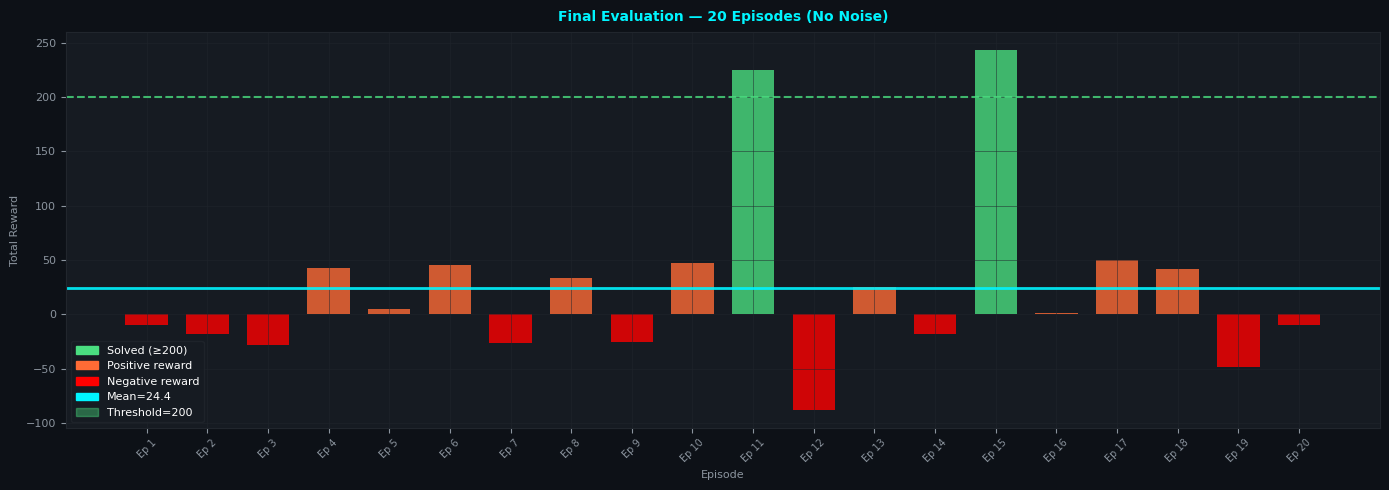

In [23]:
# ── Multi-episode evaluation ──────────────────────────────────────────
N_EVAL = 20
eval_env_final = gym.make('LunarLanderContinuous-v3')

final_rewards = []
for ep in range(N_EVAL):
    s, _ = eval_env_final.reset(seed=2000 + ep)
    done, r_sum = False, 0.0
    for _ in range(1000):
        a = agent.select_action(s, add_noise=False)
        s, r, term, trunc, _ = eval_env_final.step(a)
        r_sum += r
        if term or trunc:
            break
    final_rewards.append(r_sum)
eval_env_final.close()

print(f'\n═══════════════════════════════════════')
print(f'  Final Evaluation ({N_EVAL} episodes)')
print(f'  Mean   : {np.mean(final_rewards):.2f}')
print(f'  Std    : {np.std(final_rewards):.2f}')
print(f'  Min    : {np.min(final_rewards):.2f}')
print(f'  Max    : {np.max(final_rewards):.2f}')
print(f'  Solved : {sum(r >= 200 for r in final_rewards)}/{N_EVAL} episodes')
print(f'═══════════════════════════════════════')

# Bar chart of final eval rewards
fig, ax = plt.subplots(figsize=(14, 5), facecolor='#0d1117')
style_ax(ax, f'Final Evaluation — {N_EVAL} Episodes (No Noise)',
         'Episode', 'Total Reward')

bar_colors = [GREEN if r >= 200 else ORANGE if r >= 0 else 'red'
              for r in final_rewards]
bars = ax.bar(range(N_EVAL), final_rewards, color=bar_colors, alpha=0.8, width=0.7)
ax.axhline(200, color=GREEN, linestyle='--', linewidth=1.5, alpha=0.8, label='Solved threshold')
ax.axhline(np.mean(final_rewards), color=NEON, linestyle='-', linewidth=2,
           alpha=0.9, label=f'Mean = {np.mean(final_rewards):.1f}')
ax.set_xticks(range(N_EVAL))
ax.set_xticklabels([f'Ep {i+1}' for i in range(N_EVAL)], rotation=45, fontsize=7)

legend_handles = [
    mpatches.Patch(color=GREEN,  label='Solved (≥200)'),
    mpatches.Patch(color=ORANGE, label='Positive reward'),
    mpatches.Patch(color='red',  label='Negative reward'),
]
ax.legend(handles=legend_handles + [
    mpatches.Patch(color=NEON, label=f'Mean={np.mean(final_rewards):.1f}'),
    mpatches.Patch(color=GREEN, alpha=0.4, label='Threshold=200')
], facecolor=PANEL, edgecolor=GRID, labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('./final_eval.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

## 🔍 10. Policy Analysis — Action & Q-Value Heatmaps

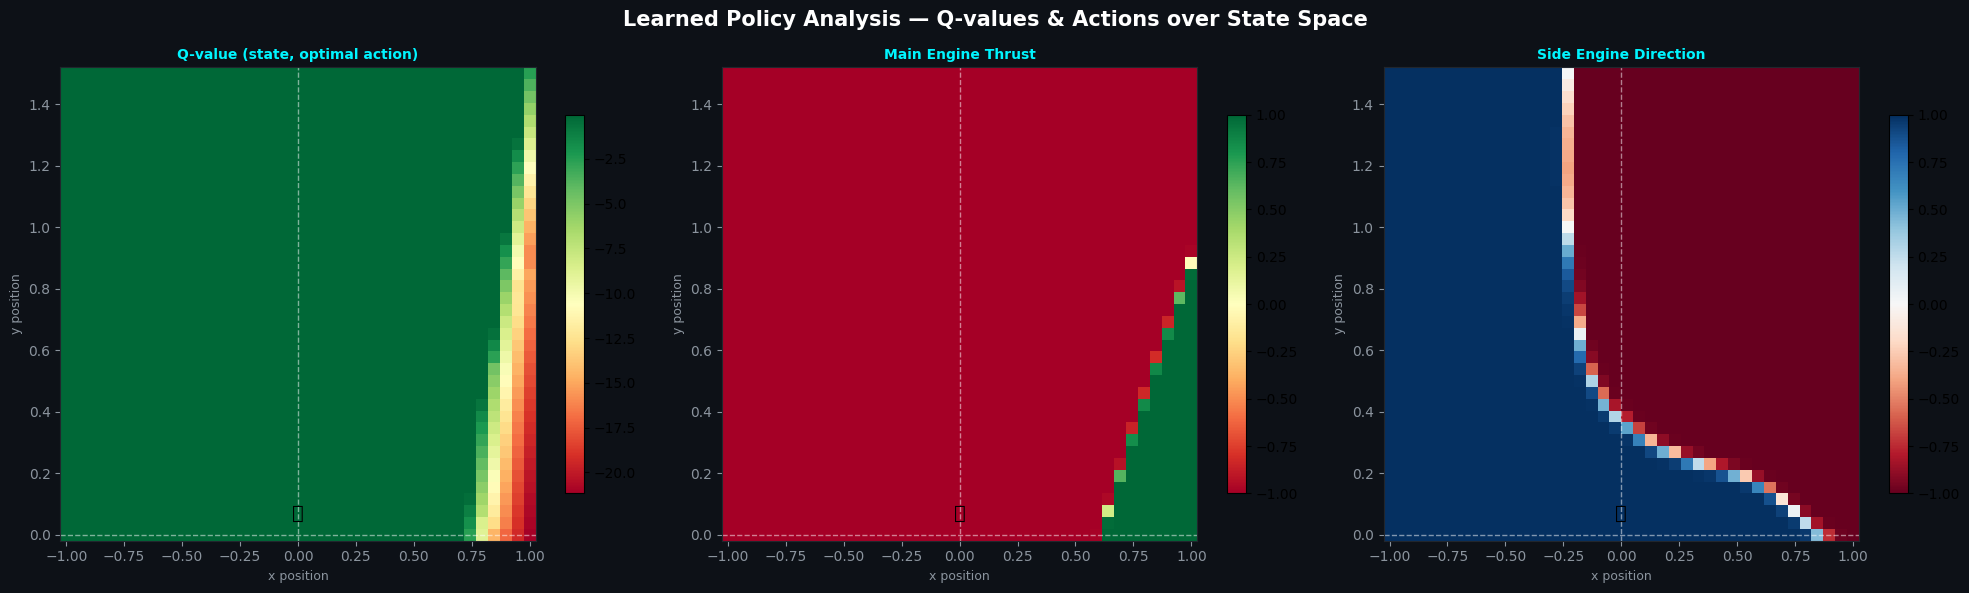

In [24]:
# ── Q-value & policy heatmaps over position space ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='#0d1117')
fig.suptitle('Learned Policy Analysis — Q-values & Actions over State Space',
             color='white', fontsize=15, fontweight='bold')

x_vals = np.linspace(-1, 1, 40)
y_vals = np.linspace(0, 1.5, 40)
XX, YY = np.meshgrid(x_vals, y_vals)

q_vals     = np.zeros_like(XX)
main_eng   = np.zeros_like(XX)
side_eng   = np.zeros_like(XX)

agent.actor.eval()
agent.critic.eval()

with torch.no_grad():
    for i in range(len(y_vals)):
        for j in range(len(x_vals)):
            # Build a representative state: [x, y, 0, 0, 0, 0, 0, 0]
            state = np.array([XX[i,j], YY[i,j], 0, -0.1, 0, 0, 0, 0],
                             dtype=np.float32)
            s_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            a_t = agent.actor(s_t)
            q   = agent.critic(s_t, a_t).item()

            q_vals[i,j]   = q
            main_eng[i,j] = a_t[0,0].item()
            side_eng[i,j] = a_t[0,1].item()

agent.actor.train()
agent.critic.train()

plot_data = [
    (q_vals,   'Q-value (state, optimal action)', 'RdYlGn'),
    (main_eng, 'Main Engine Thrust',               'RdYlGn'),
    (side_eng, 'Side Engine Direction',            'RdBu'),
]

for ax, (data, title, cmap) in zip(axes, plot_data):
    ax.set_facecolor(PANEL)
    im = ax.pcolormesh(XX, YY, data, cmap=cmap, shading='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, color=NEON, fontsize=10, fontweight='bold')
    ax.set_xlabel('x position', color='#8b949e', fontsize=9)
    ax.set_ylabel('y position', color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    # Mark landing pad
    ax.axvline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)
    ax.axhline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)
    ax.text(0, 0.05, '🎯', ha='center', fontsize=14)

plt.tight_layout()
plt.savefig('./policy_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 📋 11. Summary

In [ ]:
print('══════════════════════════════════════════════════════════════')
print('           DDPG LunarLander Training — Final Summary')
print('══════════════════════════════════════════════════════════════')
print(f'  Environment    : LunarLanderContinuous-v3')
print(f'  State dim      : {obs_dim}')
print(f'  Action dim     : {act_dim}  (continuous)')
print()
print('  Training:')
print(f'    Episodes     : {len(episode_rewards)}')
print(f'    Total steps  : {total_steps:,}')
print(f'    Best eval    : {best_eval:.2f}')
print(f'    Final avg100 : {np.mean(episode_rewards[-100:]):.2f}')
print()
print('  Final Evaluation (20 eps, no noise):')
print(f'    Mean         : {np.mean(final_rewards):.2f}')
print(f'    Std          : {np.std(final_rewards):.2f}')
print(f'    Solved       : {sum(r>=200 for r in final_rewards)}/20')
print()
print('  Saved files:')
for fname in sorted(os.listdir('./')):
    if fname.endswith(('.pt', '.gif', '.png')):
        size = os.path.getsize(f'./{fname}') / 1024
        print(f'    {fname:40s}  {size:.1f} KB')
print('══════════════════════════════════════════════════════════════')